# Climate DT and ERA5

In this exercise we will explore ways to visualize global HEALPix data and compare the ClimateDT outputs to the ERA5 reanalysis.

ERA5 is a reanalysis dataset combining model data with observations to form a consistent, global collection of past climate and weather conditions from 1940 onwards. It provides hourly values with a spatial resolution of 0.25 degrees. To keep this exercise computationally light, we will utilize [monthly averaged ERA5 data](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-monthly-means) of a single-level variable. The file is already provided to you in the same directory as this script (ERA5-monthly-2000-06-ssrd.grib).

Similarly, the ClimateDT data portfolio includes monthly data that we will request through polytope and compare against ERA5.

**Steps in this exercise:**  
- Download a radiation variable from the monthly historical ClimateDT outputs 
- Open an ERA5 dataset from a grib file
- Produce a quick visualization of the HEALPix data without interpolation
- Change the zoom level of the HEALPix grid
- Regrid high resolution HEALPix data to ERA5 grid, then calculate and plot a map of the bias

In [1]:
import earthkit
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Step 1: Requesting data

**Task:** Make a polytope request for the monthly mean from June 2000 of the variable avg_sdswrf ("Time-mean surface downward short-wave radiation flux", W/m2). You can either download the file or keep it in memory.

**Reminder:** You can explore the variables in the Data Catalogue of the [Climate DT User Guide](https://platform.destine.eu/services/documents-and-api/doc/?service_name=climate-dt-user-guide)

In [2]:
address="polytope.lumi.apps.dte.destination-earth.eu"

request = {
     'activity': 'baseline',
     'class': 'd1',
     'dataset': 'climate-dt',
     'experiment': 'hist',
     'expver': '0001',
     'model': 'ifs-fesom',
     'generation': '2',
     'realization': '1',
     'resolution': 'high',
     'year': '2000',
     'month': '6',
     'stream': 'clmn',
     'type': 'fc',
     'levtype': 'sfc',
     'param': '235035',
}

## Gets data to memory
data = earthkit.data.from_source(
    "polytope",
    "destination-earth",
    request,
    stream=False,
    address = address
)

## save to file
#data.to_target("file","IFS-FESOM-monthly-hist-2000-06-sdswrf.grib")


### Step 2: Load both datasets (ERA5 and ClimateDT) into Xarray

**Task:** Open the given ERA5 grib file (also containing surface downward solar radiation data) as an Xarray dataset, and also open the ClimateDT data with Xarray.

**Hint:** To open the ERA5 data as an Xarray dataset, you can use e.g. the xr.open_dataset() function with the argument: engine = "cfgrib". 

In [3]:
import cfgrib

era5_file = 'ERA5-monthly-2000-06-ssrd.grib'
era5_ds = xr.open_dataset(era5_file, engine = "cfgrib")

ds = data.to_xarray()

#era5_ds = cfgrib.open_datasets(era5_file) # <- another option

Ignoring index file 'ERA5-monthly-2000-06-ssrd.grib.5b7b6.idx' older than GRIB file


### Step 3: Plot the HEALPix data

**Task:** Use the hp.mollview() function to produce a Mollweide projection view of the HEALPix data. This is an easy way to get a quick look at the data without having to interpolate it to a lon-lat grid.

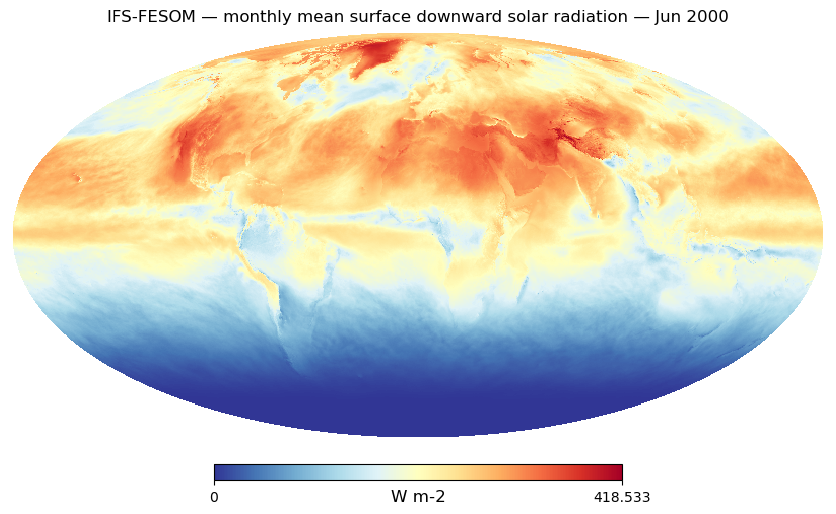

In [4]:
import healpy as hp

hp.mollview(ds["avg_sdswrf"].values, title="IFS-FESOM — monthly mean surface downward solar radiation — Jun 2000",
            unit="W m-2", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

### Step 4: Changing the zoom level of HEALPix data

**Task:** Utilize the hierarchical nature of HEALPix to decrease the resolution of the data by changing the Nside values. For example, choose the Nside value that corresponds to a resolution of about 200 km on Earth (see the slides). Plot the resulting map.

**Hint:** You can use hp.pixelfunc.ud_grade() to change the Nside values.

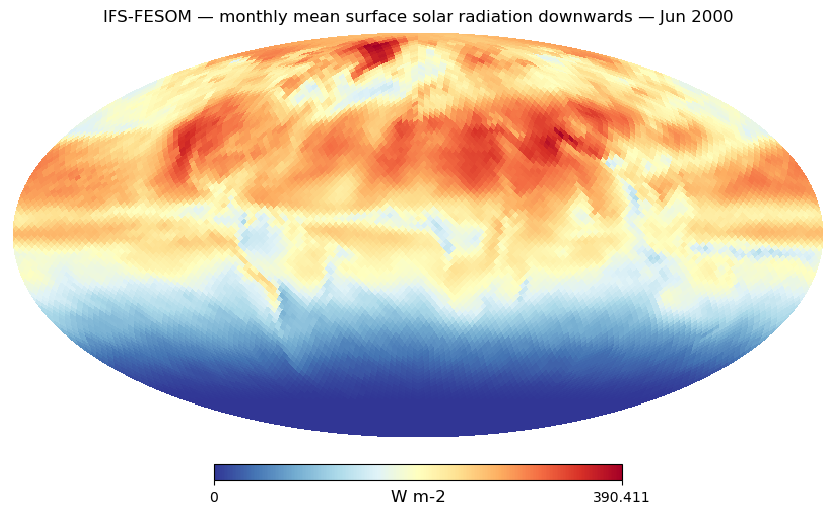

In [13]:
map_128 = hp.pixelfunc.ud_grade(ds["avg_sdswrf"].values, nside_out=32, order_in="NEST")
hp.mollview(map_128, title="IFS-FESOM — monthly mean surface solar radiation downwards — Jun 2000",
            unit="W m-2", cmap="RdYlBu_r", nest=True, flip='geo')
plt.show()

### Step 5: Interpolate the data and convert units

**Task:** Interpolate the HEALPix data into the ERA5 grid so that in can be compared against ERA5. Make an xarray dataset out of the regridded data like before. Also, the ERA5 radiation data has units of J/m2, with an accumulation period of 1 day. To convert this into the same units as the ClimateDT data (W/m2), divide by the number of seconds in a day.

**Reminder:** You can use e.g. the earthkit.regrid.interpolate() function shown earlier. 

In [6]:
# Interpolation from HEALPix to 0.25x0.25
data_latlon = earthkit.regrid.interpolate(data, out_grid={"grid": [0.25,0.25]}, method="linear")
ds_latlon = data_latlon.to_xarray()
# ERA5 units from J/m2 to W/m2
era5_ds = era5_ds/86400

### Step 6: Calculating bias

**Task:** Calculate the bias between the two datasets (ClimateDT - ERA5).

In [7]:
bias = ds_latlon["avg_sdswrf"].values - era5_ds["ssrd"].values
bias

array([[-1.09992981, -1.09992981, -1.09992981, ..., -1.09992981,
        -1.09992981, -1.09992981],
       [-5.77404808, -5.76327683, -5.75373922, ..., -5.80641413,
        -5.79561694, -5.78482819],
       [-7.15946731, -7.16209834, -7.15305653, ..., -7.16445388,
        -7.1665807 , -7.16887564],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(721, 1440))

### Step 7: Plotting the bias

**Task:** Create a map showing the bias between the datasets.

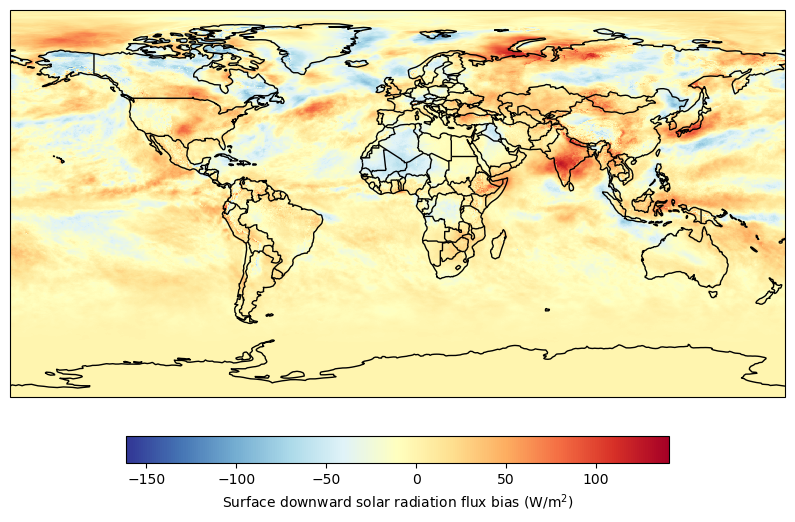

In [8]:
import numpy as np

lons, lats = ds_latlon.longitude.values, ds_latlon.latitude.values
lo, la = np.meshgrid(lons, lats)

fig, ax = plt.subplots(figsize=(10,10),subplot_kw={'projection': ccrs.PlateCarree()})
pcm = ax.pcolormesh(lo, la, bias, transform=ccrs.PlateCarree(), cmap='RdYlBu_r')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
plt.colorbar(pcm, ax=ax, shrink=0.7, pad=0.05, location="bottom", label="Surface downward solar radiation flux bias (W/m$^2$)")
plt.show()
